In [2]:
import csv
import pandas as pd
import numpy as np
from matplotlib import cm
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm

from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('thesis__data.csv', usecols = ['YEAR', 'AGE', 'MORTSTAT', 'MORTDODY', 'SEX'])

In [4]:
# define birth year (might not be exactly correct, eg born in sept and interviewed in february)
df['BIRTHYR'] = df['YEAR'] - df['AGE']

# restrict to samples whose mortality status is tracked
df = df[(df['MORTSTAT'] == 1) | (df['MORTSTAT'] == 2)]

In [5]:
age_min = 25
age_max = 80
years = range(1990, 2020)
ages = range(age_min, age_max + 1)

# emphirical mortality rates:
df_q_male = pd.DataFrame(index=years, columns=ages)
df_q_female = pd.DataFrame(index=years, columns=ages)

# emphirical log mortality rates:
df_log_q_male = pd.DataFrame(index=years, columns=ages)
df_log_q_female = pd.DataFrame(index=years, columns=ages)

for t in years:
    
    # people who are alive on 1. January of year t (and also surveyed that year or before) 
    df_t = df[(df['MORTDODY'] >= t) & (df['YEAR'] <= t)].copy()
    
    # define age of each person in year t
    df_t['AGE_YEAR_t'] = t - df_t['BIRTHYR']

    # restrict to ppl between 30 and 80 in year t
    df_t = df_t[(df_t['AGE_YEAR_t'] >= age_min) & (df_t['AGE_YEAR_t'] <= age_max)]
    
    # separate male and female
    df_t_male = df_t[df_t['SEX'] == 1]
    df_t_female = df_t[df_t['SEX'] == 2]
    
    # df of ppl who died in year t per gender
    df_t_male_dead = df_t_male[df_t_male['MORTDODY'] == t].copy()
    df_t_female_dead = df_t_female[df_t_female['MORTDODY'] == t].copy()

    # number of people alive on 1. January in year t (and surveyed before)
    E_male = df_t_male['AGE_YEAR_t'].value_counts().sort_index()
    E_female = df_t_female['AGE_YEAR_t'].value_counts().sort_index()
   
    # number of people who died in year t (and surveyed before)
    D_male = df_t_male_dead['AGE_YEAR_t'].value_counts().sort_index()
    D_female = df_t_female_dead['AGE_YEAR_t'].value_counts().sort_index()
   
    # ensure there is a 0 count for groups with no deaths
    D_male = D_male.reindex(E_male.index, fill_value=0)
    D_female = D_female.reindex(E_female.index, fill_value=0)
    
    # mortality rates, avoid division by zero
    q_male = [d/e if e > 0 else np.nan for d, e in zip(D_male, E_male)]
    q_female = [d/e if e > 0 else np.nan for d, e in zip(D_female, E_female)]

    # if mortality rate is 0 for some age x, replace it by the average of mortality rates for age x-1 and x+1
    for i in range(age_max-age_min):
        if q_male[i] == 0:
            print(f'No male of age {age_min + i} in year {t} died in year {t}.')
            q_male[i] = (q_male[i-1] + q_male[i+1]) / 2
        if q_female[i] == 0:
            print(f'No female of age {age_min + i} in year {t} died in year {t}.')
            q_female[i] = (q_female[i-1] + q_female[i+1]) / 2
     
    # store mortality rates for year t
    df_q_male.loc[t] = q_male
    df_q_female.loc[t] = q_female

    # log mortality rates
    log_q_male = np.log(q_male)
    log_q_female = np.log(q_female)
    
    #store log mortality rates for year t
    df_log_q_male.loc[t] = log_q_male
    df_log_q_female.loc[t] = log_q_female

No female of age 29 in year 1990 died in year 1990.
No female of age 25 in year 2006 died in year 2006.
No female of age 26 in year 2008 died in year 2008.
No female of age 27 in year 2011 died in year 2011.
No female of age 29 in year 2012 died in year 2012.
No female of age 25 in year 2013 died in year 2013.
No female of age 25 in year 2015 died in year 2015.
No female of age 28 in year 2017 died in year 2017.
No female of age 31 in year 2018 died in year 2018.
No female of age 25 in year 2019 died in year 2019.


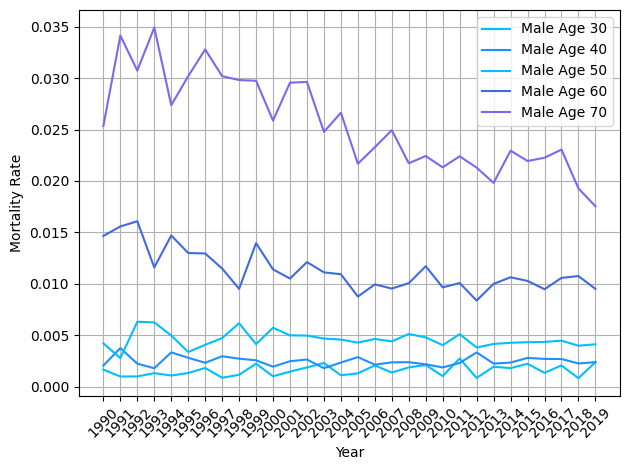

In [6]:
# chose the ages to plot between age_min and age_max
ages_to_plot = [30, 40, 50, 60, 70]

colors_blue = ["#ADD8E6", "#00BFFF", "#1E90FF", "#00BFFF", "#4169E1", "#7B68EE", "#00FFFF"] 

# --- plot for males ---
for i, age in enumerate(ages_to_plot):
    plt.plot(df_q_male.index, df_q_male[age], label=f'Male Age {age}', color=colors_blue[i+1] )

plt.xlabel('Year')
plt.ylabel('Mortality Rate')
plt.xticks(df_q_male.index, rotation=45)  
plt.legend()
plt.grid()
plt.savefig(f'mortality rates_male_continuous.jpg', format='jpg')
plt.tight_layout()
plt.show()

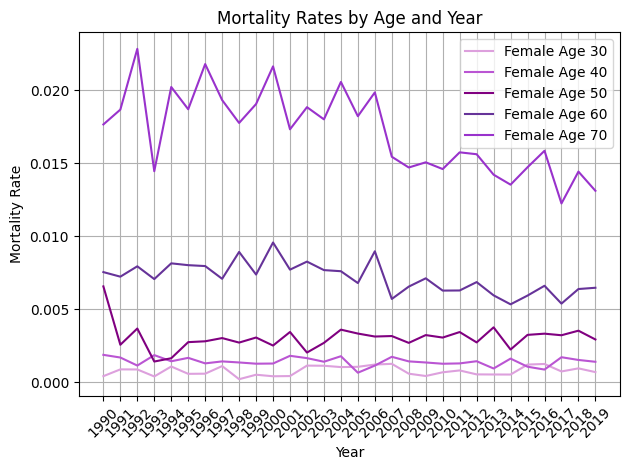

In [7]:
# do the same for women
colors_purple = ["#FFF0F5", "#D8BFD8", "#DDA0DD", "#BA55D3", "#800080", "#663399", "#9932CC", "#C71585"]  

# --- plot for females ---
for i, age in enumerate(ages_to_plot):
    plt.plot(df_q_female.index, df_q_female[age], label=f'Female Age {age}', color=colors_purple[i+2])

plt.title('Mortality Rates by Age and Year')
plt.xlabel('Year')
plt.ylabel('Mortality Rate')
plt.xticks(df_q_female.index, rotation=45) 
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(f'mortality rates_female_continuous.jpg', format='jpg')
plt.show()

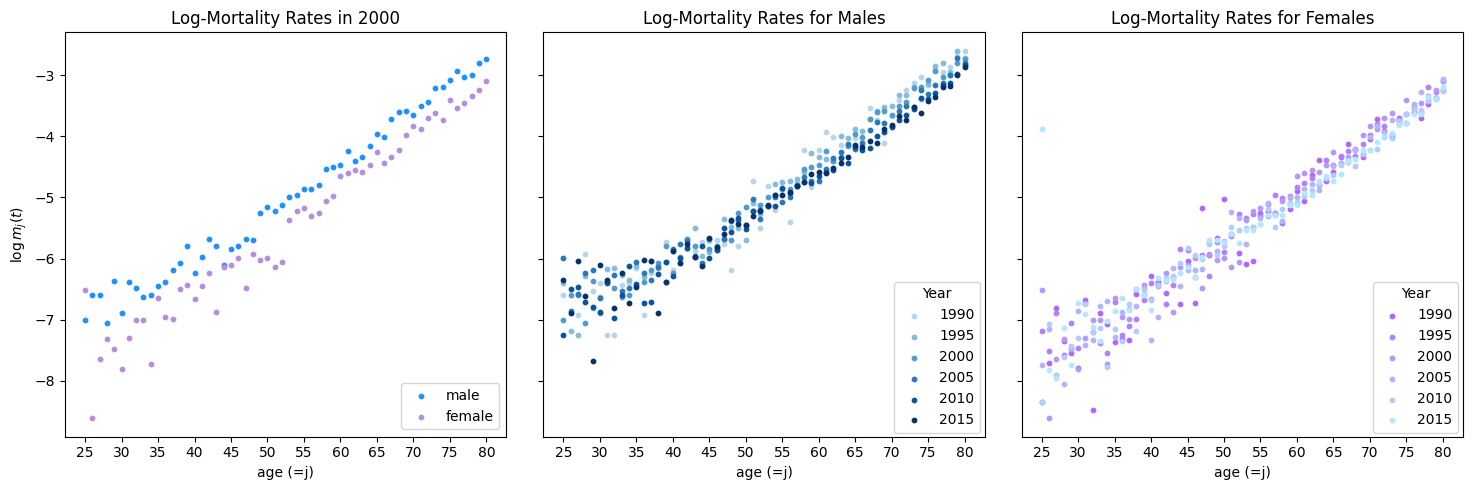

In [8]:
# pick:  
yrs_pick = [1990, 1995, 2000, 2005, 2010, 2015]
# pick: plot mortality rates at each age in year t (separate genders)
year_t = 2000

# colors females
colors_f = [mcolors.to_rgba((0.7, 0.4 + 0.1 * i, 1)) for i in range(len(yrs_pick))]
# colors male
colors_m = cm.Blues(np.linspace(0.3, 1, len(yrs_pick))) 

#___________________________________________

# set up the figure with two subplots (one for males and one for females) with shared y-axis
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

ax1.scatter(ages, df_log_q_male.loc[year_t], color = '#1E90FF', label = 'male', s=10)
ax1.scatter(ages, df_log_q_female.loc[year_t], color = '#B68EDD', label = 'female', s=10)
ax1.legend(bbox_to_anchor=(1, 0.15))
ax1.set_xlabel('age (=j)')
ax1.set_ylabel(r'$\log m_{j}(t)$')
ax1.set_title(f'Log-Mortality Rates in {year_t}')
ax1.set_xticks(np.arange(25, 81, 5))

for i, t in enumerate(yrs_pick):
    log_q_male_t = df_log_q_male.loc[t].values  
    ax2.scatter(ages, log_q_male_t, color=colors_m[i], label=str(t), s=10)

ax2.set_xlabel('age (=j)')
ax2.set_title('Log-Mortality Rates for Males')
ax2.legend(title='Year', bbox_to_anchor=(0.78, 0.4), loc='upper left')
ax2.set_xticks(np.arange(25, 81, 5))

for i, t in enumerate(yrs_pick):
    log_q_female_t = df_log_q_female.loc[t].values  
    ax3.scatter(ages, log_q_female_t, color=colors_f[i], label=str(t), s=10)

ax3.set_xlabel('age (=j)')
ax3.set_title('Log-Mortality Rates for Females')
ax3.legend(title='Year', bbox_to_anchor=(0.78, 0.4), loc='upper left')
ax3.set_xticks(np.arange(25, 81, 5))

plt.tight_layout() 
plt.savefig('combined_mortality_rates.jpg', format='jpg')
plt.show()

In [9]:
# colours for rest

In [10]:
custom_cmap_f = LinearSegmentedColormap.from_list("CustomPurples", [colors_f[5], colors_f[4], colors_f[0]])
custom_cmap_m = LinearSegmentedColormap.from_list("CustomBabyBlues",  [colors_m[0], colors_m[1], colors_m[5]])

In [11]:
# regession fitting:

In [12]:
# choose SEX :male='male', female='female'
sex = 'male'

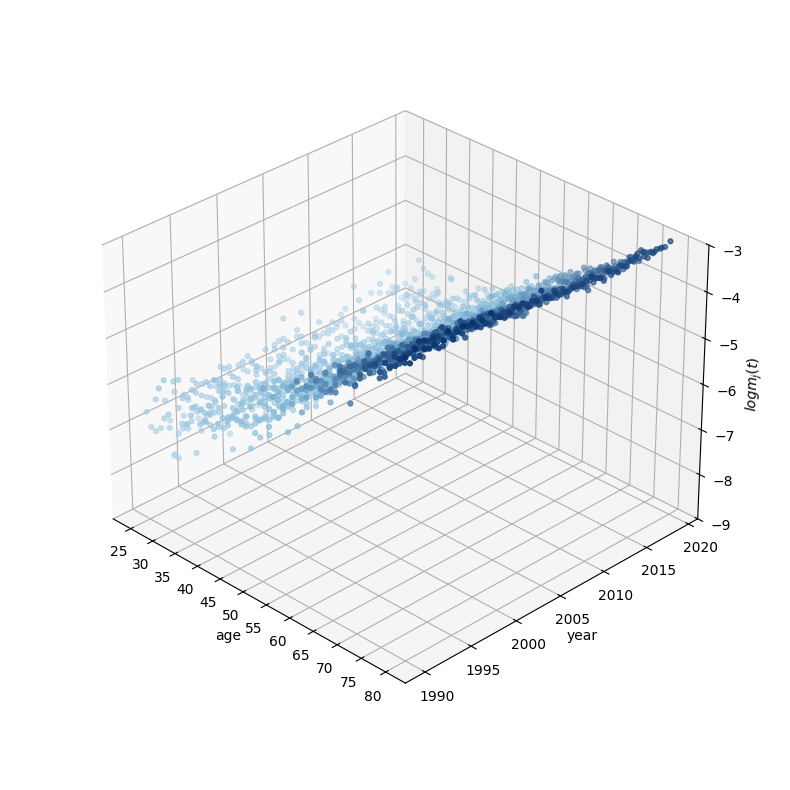

In [13]:
if sex == 'female':
    # prepare data for plotting
    x_values = df_log_q_female.columns.values    # X-axis values (age)
    y_values = df_log_q_female.index.values      # Y-axis values (time)
    z_values = df_log_q_female.values.flatten()  # Z-axis values
    x_mesh, y_mesh = np.meshgrid(x_values, y_values)
    # plot
    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_mesh.flatten(), y_mesh.flatten(), z_values, c=z_values, cmap=custom_cmap_f, s=12)
elif sex == 'male':
    # prepare data for plotting
    x_values = df_log_q_male.columns.values    # X-axis values (age)
    y_values = df_log_q_male.index.values      # Y-axis values (time)
    z_values = df_log_q_male.values.flatten()  # Z-axis values
    x_mesh, y_mesh = np.meshgrid(x_values, y_values)
    # plot
    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x_mesh.flatten(), y_mesh.flatten(), z_values, c=z_values, cmap=custom_cmap_m, s=12)
    
ax.set_zlim(-9, -3)
ax.set_xlabel('age')
ax.set_ylabel('year')
ax.set_zlabel(r'$logm_{j}(t)$')
ax.set_xticks(np.arange(25, 81, 5))
ax.view_init(elev=30, azim=-45)
ax.set_box_aspect(None, zoom=0.85) 
plt.savefig(f'data_{sex}3D.jpg', format='jpg')
plt.tight_layout()
plt.show()

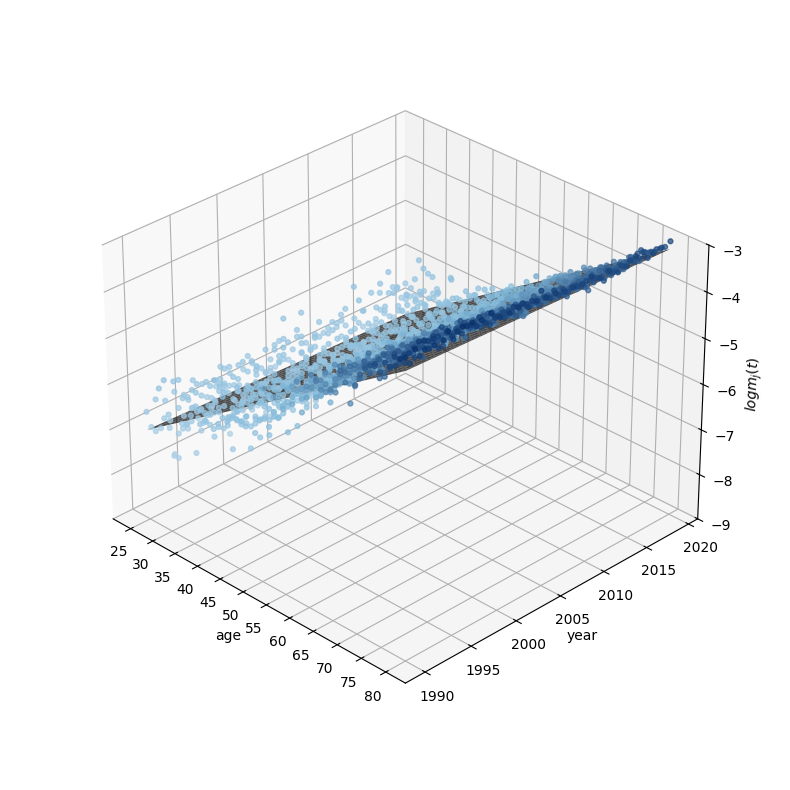

In [14]:
# reshape for linear regression
X = np.column_stack((x_mesh.flatten(), y_mesh.flatten()))
y = z_values

# fit the model
model = LinearRegression()
model.fit(X, y)

# predict values to create a plane
y_predicted = model.predict(X).reshape(x_mesh.shape)

# create empty figure and a 3D axis
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

if sex == 'female':
    # plot the fitted plane
    ax.plot_surface(x_mesh, y_mesh, y_predicted, color='black', alpha=0.7, label='2D Linear Regression Plane')
    # plot the scatter plot
    ax.scatter(x_mesh.flatten(), y_mesh.flatten(), z_values, c=z_values, s=12, cmap=custom_cmap_f)
elif sex == 'male':
    # plot the fitted plane
    ax.plot_surface(x_mesh, y_mesh, y_predicted, color='black', alpha=0.7, label='2D Linear Regression Plane')
    # plot the scatter plot
    ax.scatter(x_mesh.flatten(), y_mesh.flatten(), z_values, c=z_values, cmap=custom_cmap_m, s=12, alpha=0.7)

ax.set_zlim(-9, -3) 
ax.set_xlabel('age')
ax.set_ylabel('year')
ax.set_zlabel(r'$logm_{j}(t)$')
ax.set_xticks(np.arange(25, 81, 5))
ax.view_init(elev=30, azim=-45)  
plt.tight_layout()
ax.set_box_aspect(None, zoom=0.85) 
plt.savefig(f'fit_data_{sex}3D.jpg', format='jpg')
plt.show()

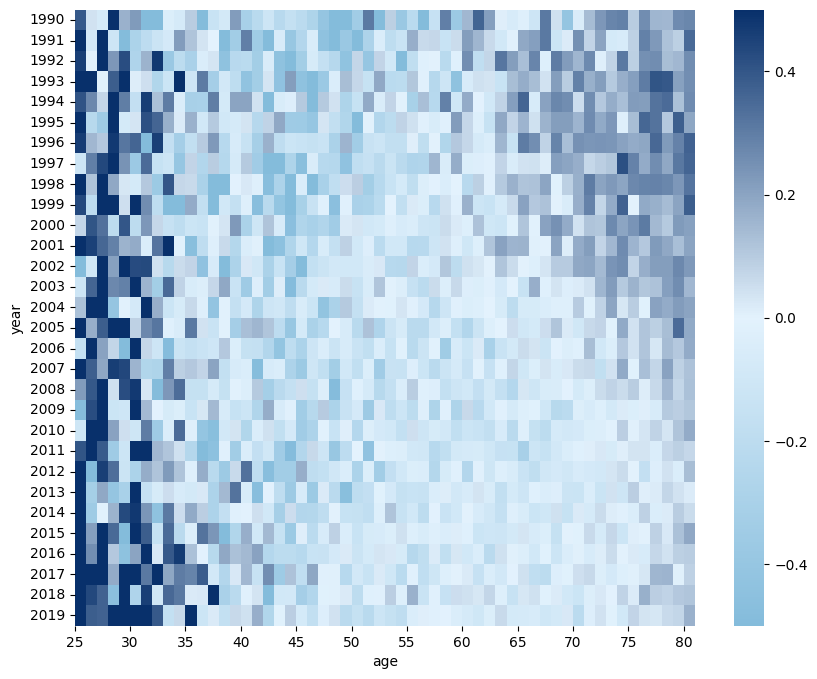

In [15]:
df_z_values = pd.DataFrame(z_values.reshape(x_mesh.shape), index=df_log_q_male.index, columns=df_log_q_male.columns)
df_z_predicted = pd.DataFrame(y_predicted, index=df_log_q_male.index, columns=df_log_q_male.columns)
df_z_diff = df_z_values - df_z_predicted

df_z_diff = df_z_diff.astype(float)
plt.figure(figsize=(10, 8))  

if sex == 'female':
    map_min = -0.5
    map_max = 0.5
    norm = TwoSlopeNorm(vmin=map_min, vcenter=0, vmax=map_max)
    custom_cmap_f = LinearSegmentedColormap.from_list("CustomPurples", [colors_f[5], "#FFEBEE", colors_f[0]])
    sns.heatmap(df_z_diff, cmap=custom_cmap_f, annot=False, norm=norm)
elif sex == 'male':
    map_min = -0.5
    map_max = 0.5
    norm = TwoSlopeNorm(vmin=map_min, vcenter=0, vmax=map_max)
    custom_cmap_m = LinearSegmentedColormap.from_list("CustomBabyBlues",  [colors_m[1], "#E3F2FD", colors_m[5]])
    sns.heatmap(df_z_diff, cmap=custom_cmap_m, annot=False, norm=norm)
    
plt.xticks(ticks=np.arange(0, len(df_z_diff.columns), 5), labels=df_z_diff.columns[::5], rotation=0)
plt.xlabel('age')
plt.ylabel('year')
plt.savefig(f'heatmap_{sex}3D.jpg', format='jpg')
plt.show()